# Solve LP

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from itertools import product as iterproduct
from pulp import LpStatus, value, constants


# ══════════════════════════════════════════════════════════════════════════════
# Shared helpers
# ══════════════════════════════════════════════════════════════════════════════

def _is_mip(model):
    return any(v.cat in (constants.LpInteger, constants.LpBinary)
               for v in model.variables())

def _is_binary(model):
    return all(v.cat == constants.LpBinary for v in model.variables())

def _get_coeffs(constraint, variables):
    coeffs = {v.name: constraint.get(v, 0) for v in variables}
    b = -constraint.constant
    return coeffs, b

def _constraint_mask_2d(constraint, x1_var, x2_var, X1, X2):
    a1 = constraint.get(x1_var, 0)
    a2 = constraint.get(x2_var, 0)
    b  = -constraint.constant
    lhs = a1 * X1 + a2 * X2
    if constraint.sense == -1: return lhs <= b + 1e-9
    if constraint.sense ==  1: return lhs >= b - 1e-9
    return np.abs(lhs - b) <= 1e-7

def _lp_binding(model):
    return [n for n, c in model.constraints.items()
            if c.slack is not None and abs(c.slack) < 1e-7]

def _lp_multiple_optima(model):
    def at_bound(v):
        val = value(v)
        if v.lowBound is not None and abs(val - v.lowBound) < 1e-7: return True
        if v.upBound  is not None and abs(val - v.upBound)  < 1e-7: return True
        return False
    has_var = any(v.dj is not None and abs(v.dj) < 1e-7 and at_bound(v)
                  for v in model.variables()
                  if v.lowBound is not None or v.upBound is not None)
    has_con = any(c.pi is not None and abs(c.pi) < 1e-7 and abs(c.slack) < 1e-7
                  for c in model.constraints.values())
    return has_var or has_con

def _mip_binding(model, variables):
    vals = {v.name: value(v) for v in variables}
    binding = []
    for name, c in model.constraints.items():
        coeffs, b = _get_coeffs(c, variables)
        lhs_val = sum(coeffs[v.name] * vals[v.name] for v in variables)
        slack = b - lhs_val if c.sense == -1 else lhs_val - b
        if abs(slack) < 1e-7:
            binding.append(name)
    return binding

def _eval_objective(model, variables, assignment):
    return sum(model.objective.get(v, 0) * assignment[v.name] for v in variables)

def _check_feasible(model, variables, assignment):
    for c in model.constraints.values():
        lhs = sum(c.get(v, 0) * assignment[v.name] for v in variables)
        b   = -c.constant
        if c.sense == -1 and lhs > b + 1e-9: return False
        if c.sense ==  1 and lhs < b - 1e-9: return False
        if c.sense ==  0 and abs(lhs - b) > 1e-7: return False
    return True

def _enumerate_binary(model, variables):
    n = len(variables)
    results = []
    for combo in iterproduct([0, 1], repeat=n):
        assignment = {variables[i].name: float(combo[i]) for i in range(n)}
        feas = _check_feasible(model, variables, assignment)
        obj  = _eval_objective(model, variables, assignment)
        results.append((obj, assignment, feas))
    return results


# ══════════════════════════════════════════════════════════════════════════════
# 2-variable plot
# ══════════════════════════════════════════════════════════════════════════════

def _plot_2d(model, variables, opt_x, opt_Z, mip,
             var_names, plot_range, n_points, iso_progression, figsize):

    x1_var, x2_var = variables
    lo, hi = plot_range
    x1_line = np.linspace(lo, hi, n_points)
    c1 = model.objective.get(x1_var, 0)
    c2 = model.objective.get(x2_var, 0)

    X1c, X2c = np.meshgrid(x1_line, np.linspace(lo, hi, n_points))
    cont_masks = [X1c >= 0, X2c >= 0]

    if mip:
        i_vals = np.arange(int(np.floor(lo)), int(np.ceil(hi)) + 1, dtype=float)
        XI, YI = np.meshgrid(i_vals, i_vals)
        int_feas = (XI >= 0) & (YI >= 0)

    for constraint in model.constraints.values():
        cont_masks.append(_constraint_mask_2d(constraint, x1_var, x2_var, X1c, X2c))
        if mip:
            int_feas &= _constraint_mask_2d(constraint, x1_var, x2_var, XI, YI)

    cont_feasible = np.logical_and.reduce(cont_masks)

    fig, ax = plt.subplots(figsize=figsize)
    colors = ['blue', 'red', 'orange', 'brown', 'magenta', 'cyan', 'olive']
    cidx = 0

    for name, constraint in model.constraints.items():
        a1 = constraint.get(x1_var, 0)
        a2 = constraint.get(x2_var, 0)
        b  = -constraint.constant
        if (a1 == 0) != (a2 == 0) and b == 0:
            cidx += 1; continue
        sense_str = {-1: r'\leq', 0: '=', 1: r'\geq'}[constraint.sense]
        parts = ([f'{a1:g}{var_names[0]}'] if a1 else []) + \
                ([f'{a2:g}{var_names[1]}'] if a2 else [])
        label = f'${"+ ".join(parts)} {sense_str} {b:g}$ ({name})'
        color = colors[cidx % len(colors)]
        if a2 != 0:
            ax.plot(x1_line, (b - a1 * x1_line) / a2, label=label, color=color, lw=2)
        elif a1 != 0:
            ax.axvline(b / a1, label=label, color=color, lw=2)
        cidx += 1

    ax.contourf(X1c, X2c, cont_feasible.astype(int),
                levels=[0.5, 1.5], colors=['green'], alpha=0.20)
    ax.fill_between([], [], [], color='green', alpha=0.20,
                    label='Feasible Region' + (' (LP relaxation)' if mip else ''))

    if mip:
        Z_int = c1 * XI + c2 * YI
        non_opt = int_feas & (np.abs(Z_int - opt_Z) >= 1e-6)
        opt_int = int_feas & (np.abs(Z_int - opt_Z)  < 1e-6)
        ax.scatter(XI[non_opt], YI[non_opt], color='green', s=25, zorder=4, alpha=0.6,
                   label='Feasible integer points')
        if np.any(opt_int):
            ax.scatter(XI[opt_int], YI[opt_int], color='gold', edgecolors='black',
                       s=80, zorder=5, label=f'Optimal Z={opt_Z:g}')

    if iso_progression is None:
        iso_progression = [round(opt_Z * 0.3, 2), round(opt_Z * 0.6, 2)]
    if c2 != 0:
        for z_val, style, alpha in [(z, ':', 0.4) for z in iso_progression] + [(opt_Z, '-', 1.0)]:
            ax.plot(x1_line, (z_val - c1 * x1_line) / c2,
                    linestyle=style, color='purple', alpha=alpha,
                    label=f'Isoquant Z={z_val:g}' if z_val == opt_Z else None)

    marker, msize = ('*', 14) if mip else ('o', 8)
    ax.plot(opt_x[var_names[0]], opt_x[var_names[1]],
            marker=marker, color='black', markersize=msize, zorder=6)
    offset = (hi - lo) * 0.06
    ax.annotate(f'Optimal\n({opt_x[var_names[0]]:g}, {opt_x[var_names[1]]:g})\nZ={opt_Z:g}',
                xy=(opt_x[var_names[0]], opt_x[var_names[1]]),
                xytext=(opt_x[var_names[0]] + offset, opt_x[var_names[1]] + offset),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                fontsize=9)

    ax.set_xlim(lo, hi * 0.9); ax.set_ylim(lo, hi * 0.9)
    ax.set_xlabel(f'${var_names[0]}$', fontsize=12)
    ax.set_ylabel(f'${var_names[1]}$', fontsize=12)
    ptype = "Integer Programming (MIP)" if mip else "Linear Programming (LP)"
    ax.set_title(f'{ptype}: Feasible Region, Constraints & Isoquants', fontsize=13)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    if mip:
        ax.set_xticks(np.arange(int(lo), int(hi * 0.9) + 1))
        ax.set_yticks(np.arange(int(lo), int(hi * 0.9) + 1))
    plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Multi-variable MIP dashboard
# ══════════════════════════════════════════════════════════════════════════════

def _plot_mip_nd(model, variables, var_names, opt_x, opt_Z, figsize):
    n_vars  = len(variables)
    binary  = _is_binary(model)

    if binary and n_vars <= 20:
        all_results = _enumerate_binary(model, variables)
        feasible_results = sorted(
            [(obj, asgn) for obj, asgn, feas in all_results if feas],
            key=lambda x: x[0],
            reverse=(model.sense != 1)
        )
    else:
        feasible_results = None

    has_landscape = feasible_results is not None
    n_panels = 3 if has_landscape else 2
    fig, axes = plt.subplots(1, n_panels,
                             figsize=(figsize[0] * n_panels / 2, figsize[1] * 0.7))
    if n_panels == 1:
        axes = [axes]

    panel = 0

    if has_landscape:
        ax = axes[panel]; panel += 1
        objs = [r[0] for r in feasible_results]
        n_feas = len(objs)
        bar_colors = ['#f4c542' if abs(obj - opt_Z) < 1e-6 else '#4c9be8'
                      for obj, _ in feasible_results]
        ax.bar(range(n_feas), objs, color=bar_colors, edgecolor='black', linewidth=0.5)
        for i, (obj, asgn) in enumerate(feasible_results):
            combo_str = '(' + ', '.join(f'{int(asgn[vn]):g}' for vn in var_names) + ')'
            ax.text(i, obj + max(objs) * 0.01, combo_str,
                    ha='center', va='bottom', fontsize=6.5, rotation=45)
        ax.set_xticks(range(n_feas))
        ax.set_xticklabels([str(i + 1) for i in range(n_feas)], fontsize=8)
        ax.set_xlabel('Feasible Combinations (ranked by objective)', fontsize=9)
        ax.set_ylabel('Objective Value Z', fontsize=9)
        ax.set_title(f'Solution Landscape\n({n_feas} feasible of {2**n_vars} total)', fontsize=10)
        ax.set_ylim(0, max(objs) * 1.20)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.legend(handles=[mpatches.Patch(color='#f4c542', label=f'Optimal Z={opt_Z:g}'),
                            mpatches.Patch(color='#4c9be8', label='Feasible')], fontsize=8)

    ax = axes[panel]; panel += 1
    contrib = {v.name: model.objective.get(v, 0) * opt_x[v.name] for v in variables}
    names_list = [v.name for v in variables]
    vals_c     = [contrib[n] for n in names_list]
    selected   = [opt_x[n] > 0.5 for n in names_list]
    bar_colors2 = ['#2ecc71' if s else '#e0e0e0' for s in selected]
    bars2 = ax.bar(names_list, vals_c, color=bar_colors2, edgecolor='black', linewidth=0.6)
    for bar, val, sel in zip(bars2, vals_c, selected):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(vals_c) * 0.01,
                    f'{val:g}', ha='center', va='bottom', fontsize=9,
                    fontweight='bold' if sel else 'normal')
    ax.set_xlabel('Variable', fontsize=9)
    ax.set_ylabel('Contribution to Z', fontsize=9)
    ax.set_title(f'Optimal Solution  Z={opt_Z:g}\n'
                 f'({", ".join(n for n, s in zip(names_list, selected) if s)} selected)',
                 fontsize=10)
    ax.set_ylim(0, max(vals_c) * 1.25 if max(vals_c) > 0 else 1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(handles=[mpatches.Patch(color='#2ecc71', label='Included'),
                        mpatches.Patch(color='#e0e0e0', label='Not selected')], fontsize=8)

    ax = axes[panel]; panel += 1
    con_names, used_pcts, rhs_vals, used_vals = [], [], [], []
    for cname, c in model.constraints.items():
        coeffs, b = _get_coeffs(c, variables)
        lhs_val = sum(coeffs[v.name] * opt_x[v.name] for v in variables)
        if b == 0: continue
        pct = abs(lhs_val / b) * 100
        con_names.append(cname); used_pcts.append(min(pct, 100))
        rhs_vals.append(b); used_vals.append(lhs_val)
    if con_names:
        bar_colors3 = ['#e74c3c' if p >= 99.9 else '#f39c12' if p >= 75 else '#3498db'
                       for p in used_pcts]
        bars3 = ax.barh(con_names, used_pcts, color=bar_colors3, edgecolor='black', linewidth=0.6)
        ax.axvline(100, color='black', lw=1.5, linestyle='--')
        for bar, pct, uv, rv in zip(bars3, used_pcts, used_vals, rhs_vals):
            ax.text(min(pct + 1, 101), bar.get_y() + bar.get_height() / 2,
                    f'{uv:g} / {rv:g}  ({pct:.1f}%)', va='center', fontsize=9)
        ax.set_xlim(0, 130)
        ax.set_xlabel('Utilisation (%)', fontsize=9)
        ax.set_title('Constraint Utilisation\nat Optimal Solution', fontsize=10)
        ax.grid(axis='x', linestyle='--', alpha=0.4)
        ax.legend(handles=[mpatches.Patch(color='#e74c3c', label='Binding'),
                            mpatches.Patch(color='#f39c12', label='Tight ≥75%'),
                            mpatches.Patch(color='#3498db', label='Slack')],
                  fontsize=8, loc='lower right')

    ptype = "Binary IP" if binary else "MIP"
    fig.suptitle(f'{ptype} Analysis  —  {n_vars} Variables, '
                 f'{len(model.constraints)} Constraints',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Gantt chart
# ══════════════════════════════════════════════════════════════════════════════

def _validate_gantt_config(cfg):
    """
    Check the gantt config dict and return a normalised version.
    Raises ValueError with a helpful message on any problem.

    Supported types
    ---------------
    'assignment'
        Jobs assigned to machines; no sequencing.
        Required keys:
          machines   : list of machine ids
          jobs       : list of job ids
          durations  : dict {job_id: duration}
          x_pattern  : str with '{i}' and '{j}' placeholders, e.g. 'x{i}_{j}'
        Optional keys:
          machine_labels : dict {machine_id: str}
          job_labels     : dict {job_id: str}
          makespan_var   : name of the makespan variable (for title annotation)

    'sequenced'
        Jobs have defined start times on machines (JSP / single-machine scheduling).
        Required keys:
          machines   : list of machine ids
          jobs       : list of job ids
          durations  : dict {job_id: duration}  OR  dict {(machine_id,job_id): duration}
          start_pattern : str with '{i}' and/or '{j}' placeholders, e.g. 's{i}_{j}'
        Optional keys:
          machine_labels, job_labels, makespan_var  (same as above)
    """
    required_base = {'type', 'machines', 'jobs', 'durations'}
    missing = required_base - set(cfg)
    if missing:
        raise ValueError(f"gantt config missing keys: {missing}")

    kind = cfg['type']
    if kind == 'assignment' and 'x_pattern' not in cfg:
        raise ValueError("gantt config type='assignment' requires 'x_pattern'")
    if kind == 'sequenced' and 'start_pattern' not in cfg:
        raise ValueError("gantt config type='sequenced' requires 'start_pattern'")
    if kind not in ('assignment', 'sequenced'):
        raise ValueError(f"gantt config type must be 'assignment' or 'sequenced', got '{kind}'")

    return cfg


def _build_gantt_data(cfg, var_dict):
    """
    Parse the solved model variables using cfg and return a list of bars:
      [ {'machine': id, 'job': id, 'start': float, 'duration': float} ]
    """
    kind      = cfg['type']
    machines  = cfg['machines']
    jobs      = cfg['jobs']
    durations = cfg['durations']
    bars      = []

    if kind == 'assignment':
        pattern = cfg['x_pattern']
        # For each machine track cumulative start (jobs packed left-to-right)
        cursor = {i: 0.0 for i in machines}
        for i in machines:
            for j in jobs:
                vname = pattern.replace('{i}', str(i)).replace('{j}', str(j))
                if vname in var_dict and value(var_dict[vname]) > 0.5:
                    dur = durations[j] if j in durations else durations[(i, j)]
                    bars.append({'machine': i, 'job': j,
                                 'start': cursor[i], 'duration': dur})
                    cursor[i] += dur

    elif kind == 'sequenced':
        pattern = cfg['start_pattern']
        for i in machines:
            for j in jobs:
                vname = (pattern.replace('{i}', str(i)).replace('{j}', str(j))
                         if '{i}' in pattern and '{j}' in pattern
                         else pattern.replace('{j}', str(j)))
                if vname not in var_dict:
                    continue
                start = value(var_dict[vname])
                if start is None:
                    continue
                # duration: try (i,j) key first, then j only
                dur = durations.get((i, j), durations.get(j))
                if dur is None:
                    continue
                bars.append({'machine': i, 'job': j,
                             'start': start, 'duration': dur})

    return bars


def _plot_gantt(cfg, var_dict, opt_Z, model_name, figsize):
    """Render a Gantt chart from parsed bar data."""
    bars = _build_gantt_data(cfg, var_dict)
    if not bars:
        print("  [Gantt] No bars to plot — check your x_pattern / start_pattern.")
        return

    machines       = cfg['machines']
    jobs           = cfg['jobs']
    machine_labels = cfg.get('machine_labels', {i: f'Machine {i}' for i in machines})
    job_labels     = cfg.get('job_labels',     {j: f'Job {j}'     for j in jobs})
    makespan_var   = cfg.get('makespan_var')

    # Colour palette — one colour per job
    cmap   = cm.get_cmap('tab20', max(len(jobs), 1))
    jcolors = {j: cmap(idx) for idx, j in enumerate(jobs)}

    fig, ax = plt.subplots(figsize=figsize)

    # Machine index → y position (machines listed top-to-bottom)
    m_idx = {m: k for k, m in enumerate(reversed(machines))}

    bar_height = 0.5
    for b in bars:
        y = m_idx[b['machine']]
        ax.barh(y, b['duration'], left=b['start'],
                height=bar_height, color=jcolors[b['job']],
                edgecolor='black', linewidth=0.8)
        # Label inside bar if wide enough
        mid = b['start'] + b['duration'] / 2
        ax.text(mid, y, job_labels[b['job']],
                ha='center', va='center', fontsize=8,
                color='white' if b['duration'] > 1 else 'black',
                fontweight='bold')

    # Makespan line
    makespan = opt_Z if makespan_var else max(b['start'] + b['duration'] for b in bars)
    ax.axvline(makespan, color='red', lw=1.5, linestyle='--',
               label=f'Makespan = {makespan:g}')

    # Machine load annotations (right margin)
    for m in machines:
        load = sum(b['duration'] for b in bars if b['machine'] == m)
        y    = m_idx[m]
        ax.text(makespan + makespan * 0.01, y,
                f'Load: {load:g}', va='center', fontsize=8, color='#333333')

    # Axes
    ax.set_yticks(list(m_idx.values()))
    ax.set_yticklabels([machine_labels[m] for m in reversed(machines)], fontsize=10)
    ax.set_xlabel('Time', fontsize=11)
    ax.set_xlim(0, makespan * 1.18)
    ax.set_ylim(-0.5, len(machines) - 0.5)
    ax.set_title(f'Gantt Chart — {model_name}\nMakespan = {makespan:g}', fontsize=13)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # Legend (one entry per job)
    patches = [mpatches.Patch(color=jcolors[j], label=job_labels[j]) for j in jobs]
    ax.legend(handles=patches, loc='lower right', fontsize=8,
              title='Jobs', title_fontsize=9)

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Public entry point
# ══════════════════════════════════════════════════════════════════════════════

def analyze_lp(model, var_names=None, plot_range=(0, 20), n_points=400,
               iso_progression=None, figsize=(10, 10), gantt=None):
    """
    Solve and analyse a PuLP LP or MIP of any number of variables.

    Routing logic
    -------------
    gantt is not None  → Gantt chart (after solve + console output)
    2 variables        → feasible-region + isoquant 2D plot
    3+ variables       → three-panel MIP dashboard

    Parameters
    ----------
    model      : pulp.LpProblem
    var_names  : tuple[str] or None   variable names; None = infer from model
    plot_range : (float, float)       axis limits (2D plot only)
    n_points   : int                  grid resolution (2D plot only)
    iso_progression : list[float]     extra isoquant Z values (2D only)
    figsize    : (float, float)
    gantt      : dict or None
        When provided, a Gantt chart is drawn instead of the standard plots.
        The dict describes how to extract the schedule from the solved variables.

        Common keys
        ~~~~~~~~~~~
        type          : 'assignment' | 'sequenced'
        machines      : list of machine ids,  e.g. [0, 1, 2]
        jobs          : list of job ids,       e.g. [0, 1, 2, 3]
        durations     : {job_id: int}  or  {(machine_id, job_id): int}

        For type='assignment'
        ~~~~~~~~~~~~~~~~~~~~~
        x_pattern     : variable name template, e.g. 'x{i}_{j}'
                        {i} → machine id,  {j} → job id

        For type='sequenced'
        ~~~~~~~~~~~~~~~~~~~~~
        start_pattern : variable name template for start times, e.g. 's{i}_{j}'
                        Use both {i} and {j} for machine-job starts,
                        or just {j} for single-machine / job-level starts.

        Optional keys (both types)
        ~~~~~~~~~~~~~~~~~~~~~~~~~~
        machine_labels : {machine_id: str}   e.g. {0: 'Press', 1: 'Drill'}
        job_labels     : {job_id: str}        e.g. {0: 'Order A'}
        makespan_var   : str  name of the makespan variable in the model;
                         if given, its solved value is used as the makespan line
    """
    mip = _is_mip(model)

    # ── 1. Solve ──────────────────────────────────────────────────────────────
    model.solve()
    status_label = LpStatus[model.status]

    # ── 2. Variable order ─────────────────────────────────────────────────────
    var_dict = {v.name: v for v in model.variables()}
    if var_names is None:
        var_names = tuple(v.name for v in model.variables())
    variables = [var_dict[n] for n in var_names]

    opt_x = {n: value(var_dict[n]) for n in var_names}
    opt_Z = value(model.objective)

    # ── 3. Status ─────────────────────────────────────────────────────────────
    if status_label == "Optimal":
        if mip and _is_binary(model) and len(variables) <= 20:
            all_results = _enumerate_binary(model, variables)
            opt_count   = sum(1 for obj, _, feas in all_results
                              if feas and abs(obj - opt_Z) < 1e-6)
            has_multiple = opt_count > 1
        elif mip:
            has_multiple = False
        else:
            has_multiple = _lp_multiple_optima(model)
        output_status = "Optimal, multiple solutions" if has_multiple else "Optimal, unique solution"
    else:
        output_status = status_label

    # ── 4. Console output ─────────────────────────────────────────────────────
    problem_type = ("Binary IP" if mip and _is_binary(model)
                    else "MIP" if mip else "LP")
    print(f"[{problem_type}] Status: {output_status}")

    if status_label != "Optimal":
        print("No optimal solution to report.")
        return

    sol_str = ",  ".join(f"{n} = {opt_x[n]:g}" for n in var_names)
    print(f"Z = {opt_Z:g},  {sol_str}")

    print("\nBinding Constraints:")
    binding = _mip_binding(model, variables) if mip else _lp_binding(model)
    if binding:
        for name in binding: print(f"  - {name}")
    else:
        print("  (none)")

    # ── 5. Plot ───────────────────────────────────────────────────────────────
    if gantt is not None:
        cfg = _validate_gantt_config(gantt)
        _plot_gantt(cfg, var_dict, opt_Z, model.name, figsize)
    elif len(variables) == 2:
        _plot_2d(model, variables, opt_x, opt_Z, mip,
                 var_names, plot_range, n_points, iso_progression, figsize)
    else:
        _plot_mip_nd(model, variables, var_names, opt_x, opt_Z, figsize)

[MIP] Status: Optimal, unique solution
Z = 30,  x0 = 0,  x1 = 1,  x2 = 0,  x3 = 1

Binding Constraints:
  - Hours


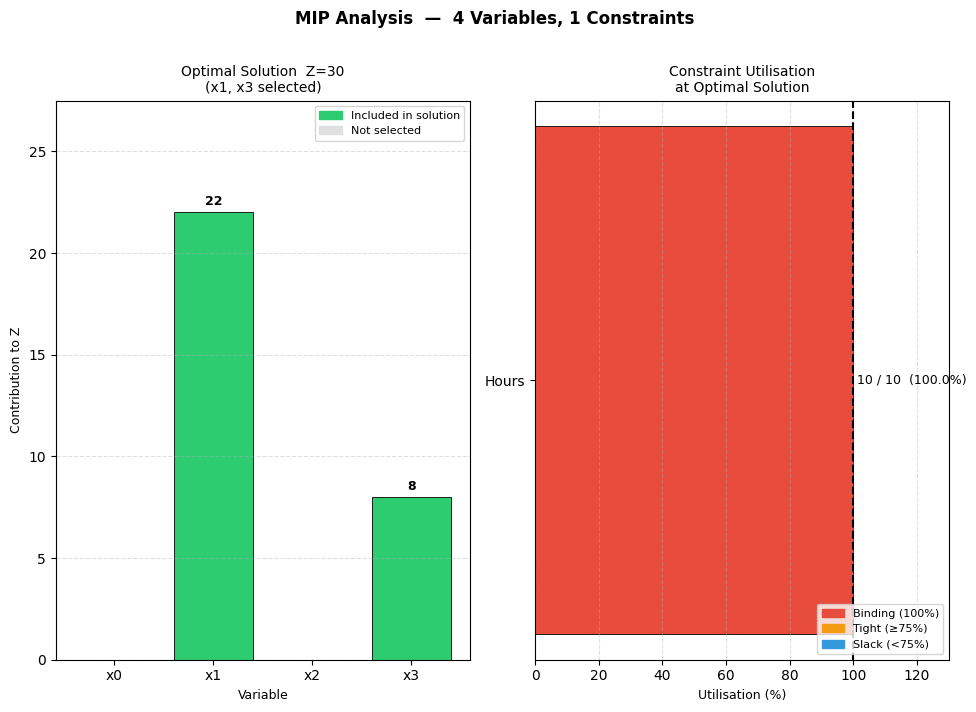

In [ ]:
from pulp import LpProblem, LpMaximize, LpVariable

model = LpProblem("Maximization_Problem", LpMaximize)
 
# No lowBound — variables are free; non-negativity added as constraints below
w = [5, 7, 4, 3]
v = [16, 22, 12, 8]

xwv = {f'x{i}': {
        'x': LpVariable(f"x{i}", cat='Binary'),
        'w': w[i],
        'v': v[i]
    }  for i in range(0,4)
}


 
model += sum(v['x']*v['v'] for v in xwv.values()), "Objective"
model += sum(v['x']*v['w'] for v in xwv.values()) <= 10, "Hours"

 
analyze_lp(model, var_names=tuple(xwv.keys()), plot_range=(0, 15))

In [ ]:
print(1)

Processing times: {0: 7, 1: 4, 2: 8, 3: 5, 4: 7, 5: 10}
[MIP] Status: Optimal, unique solution
Z = 14,  w = 14,  x0_0 = 1,  x0_1 = 0,  x0_2 = 0,  x0_3 = 0,  x0_4 = 1,  x0_5 = 0,  x1_0 = 0,  x1_1 = 1,  x1_2 = 0,  x1_3 = 0,  x1_4 = 0,  x1_5 = 1,  x2_0 = 0,  x2_1 = 0,  x2_2 = 1,  x2_3 = 1,  x2_4 = 0,  x2_5 = 0

Binding Constraints:
  - Makespan_m0
  - Makespan_m1
  - Assign_j0
  - Assign_j1
  - Assign_j2
  - Assign_j3
  - Assign_j4
  - Assign_j5


C:\Users\Muham\AppData\Local\Temp\ipykernel_16200\3494108464.py:393: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap('tab20', max(len(jobs), 1))


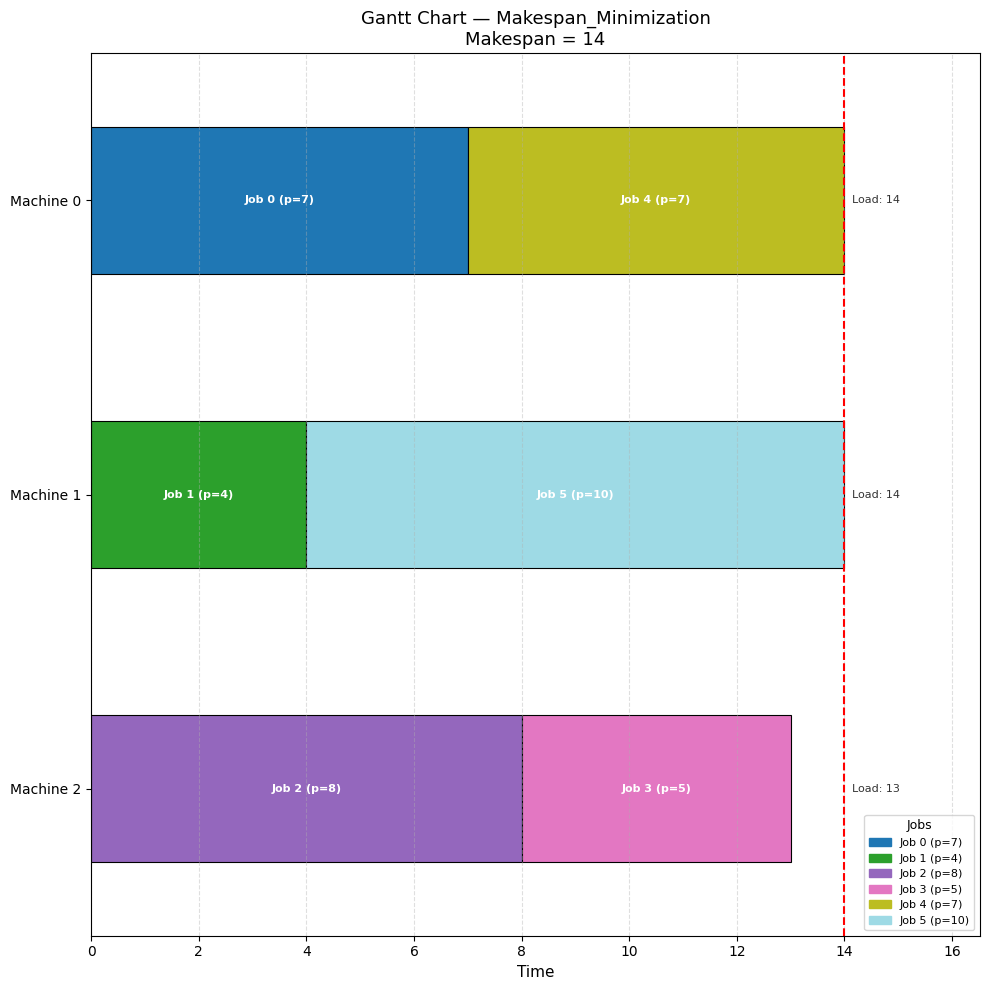

In [11]:
import numpy as np
from pulp import LpProblem, LpMinimize, LpVariable, lpSum

np.random.seed(42)

n_jobs     = 6
n_machines = 3

I = list(range(n_machines))
J = list(range(n_jobs))

p = {j: int(np.random.randint(1, 11)) for j in J}   # processing times p_j
print("Processing times:", p)

# Decision variables
x = {(i, j): LpVariable(f"x{i}_{j}", cat="Binary") for i in I for j in J}
w = LpVariable("w", lowBound=0)   # makespan

model = LpProblem("Makespan_Minimization", LpMinimize)

# Objective: min w
model += w, "Objective"

# w >= sum_j p_j * x_ij  for all i  (makespan >= load on each machine)
for i in I:
    model += w >= lpSum(p[j] * x[i, j] for j in J), f"Makespan_m{i}"

# sum_i x_ij = 1  for all j  (each job assigned to exactly one machine)
for j in J:
    model += lpSum(x[i, j] for i in I) == 1, f"Assign_j{j}"

var_names = ("w",) + tuple(f"x{i}_{j}" for i in I for j in J)

analyze_lp(
    model,
    var_names=var_names,
    gantt={
        'type'        : 'assignment',   # jobs assigned to machines, no sequencing
        'machines'    : I,
        'jobs'        : J,
        'durations'   : p,              # {job_id: processing_time}
        'x_pattern'   : 'x{i}_{j}',    # {i}=machine, {j}=job
        'makespan_var': 'w',            # draws the red dashed line at opt_Z
        'machine_labels': {i: f'Machine {i}' for i in I},
        'job_labels'    : {j: f'Job {j} (p={p[j]})' for j in J},
    }
)
